In [0]:
%run ./00_configuracion

Configuración cargada correctamente.
Ruta base: /Volumes/workspace/default/tcga_cancer_ml
Número de clases oficiales: 18


Estructura creada correctamente:
/Volumes/workspace/default/tcga_cancer_ml
/Volumes/workspace/default/tcga_cancer_ml/raw
/Volumes/workspace/default/tcga_cancer_ml/trusted
/Volumes/workspace/default/tcga_cancer_ml/refined
/Volumes/workspace/default/tcga_cancer_ml/models
/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq
/Volumes/workspace/default/tcga_cancer_ml/raw/metadata
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_long
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_matrix
/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs
/Volumes/workspace/default/tcga_cancer_ml/refined/model_metrics
/Volumes/workspace/default/tcga_cancer_ml/refined/predictions
/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations


muestras_unicas_long,filas_samples,muestras_unicas_samples,pacientes_unicos_long,genes_unicos_long
8335,8335,8335,8283,19944


In [0]:

# 1. Configuración general e imports

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize

spark.conf.set("spark.sql.shuffle.partitions", "200")

print("Configuración cargada correctamente.")
print("Ruta trusted:", TRUSTED_PATH)
print("Ruta refined:", REFINED_PATH)
print("Ruta modelos:", MODELS_PATH)

Configuración cargada correctamente.
Ruta trusted: /Volumes/workspace/default/tcga_cancer_ml/trusted
Ruta refined: /Volumes/workspace/default/tcga_cancer_ml/refined
Ruta modelos: /Volumes/workspace/default/tcga_cancer_ml/models


In [0]:
 # 2. Lectura de tablas trusted

df_long = spark.table("workspace.default.trusted_tcga_rnaseq_long_18_clases")
df_samples = spark.table("workspace.default.trusted_tcga_samples_18_clases")

print("Muestras únicas:", df_samples.count())
print("Pacientes únicos:", df_samples.select("patient_id").distinct().count())
print("Genes únicos:", df_long.select("gene_id_base").distinct().count())

print("Distribución por tipo de cáncer:")
display(
    df_samples
    .groupBy("cancer_type")
    .agg(
        F.count("*").alias("n_muestras"),
        F.countDistinct("patient_id").alias("n_pacientes")
    )
    .orderBy(F.desc("n_muestras"))
)

Muestras únicas: 8335
Pacientes únicos: 8283
Genes únicos: 19944
Distribución por tipo de cáncer:


cancer_type,n_muestras,n_pacientes
BRCA,1106,1095
UCEC,549,545
KIRC,537,533
LUAD,529,517
HNSC,520,520
LGG,516,516
THCA,505,505
LUSC,501,501
PRAD,501,497
COAD,471,458


In [0]:
# 2.1 Validación rápida de consistencia
validacion_consistencia = spark.sql("""
    SELECT
        (SELECT COUNT(DISTINCT sample_id)
         FROM workspace.default.trusted_tcga_rnaseq_long_18_clases) AS muestras_unicas_long,

        (SELECT COUNT(*)
         FROM workspace.default.trusted_tcga_samples_18_clases) AS filas_samples,

        (SELECT COUNT(DISTINCT sample_id)
         FROM workspace.default.trusted_tcga_samples_18_clases) AS muestras_unicas_samples,

        (SELECT COUNT(DISTINCT patient_id)
         FROM workspace.default.trusted_tcga_rnaseq_long_18_clases) AS pacientes_unicos_long,

        (SELECT COUNT(DISTINCT gene_id_base)
         FROM workspace.default.trusted_tcga_rnaseq_long_18_clases) AS genes_unicos_long
""")

display(validacion_consistencia)

# Verificar que no haya duplicados por muestra en la tabla de muestras
duplicados_sample = (
    df_samples
    .groupBy("sample_id")
    .agg(F.count("*").alias("n_filas"))
    .filter(F.col("n_filas") > 1)
)

print("Duplicados por sample_id:", duplicados_sample.count())

muestras_unicas_long,filas_samples,muestras_unicas_samples,pacientes_unicos_long,genes_unicos_long
8335,8335,8335,8283,19944


Duplicados por sample_id: 0


In [0]:
# 3. Selección de genes más variables entre clases
N_GENES = 100  # Reducido a 100 para evitar MODEL_SIZE_OVERFLOW_EXCEPTION en serverless (límite 268 MB)

try:
    df_genes_variables = spark.table("workspace.default.refined_eda_genes_mas_variables")
    print("Usando tabla refined_eda_genes_mas_variables del EDA.")
except Exception as e:
    print("No se encontró refined_eda_genes_mas_variables. Se calculará desde la tabla trusted.")
    print("Detalle:", e)

    df_genes_variables = spark.sql("""
        WITH media_por_clase AS (
            SELECT
                gene_id_base,
                gene_name,
                cancer_type,
                AVG(log2_tpm) AS media_clase
            FROM workspace.default.trusted_tcga_rnaseq_long_18_clases
            GROUP BY gene_id_base, gene_name, cancer_type
        ),
        variabilidad AS (
            SELECT
                gene_id_base,
                gene_name,
                AVG(media_clase) AS media_global,
                STDDEV(media_clase) AS sd_entre_clases,
                MAX(media_clase) - MIN(media_clase) AS rango_entre_clases
            FROM media_por_clase
            GROUP BY gene_id_base, gene_name
        )
        SELECT *
        FROM variabilidad
        ORDER BY sd_entre_clases DESC
    """)

genes_modelo = [
    row["gene_id_base"]
    for row in (
        df_genes_variables
        .orderBy(F.desc("sd_entre_clases"))
        .limit(N_GENES)
        .select("gene_id_base")
        .collect()
    )
]

print("Número de genes seleccionados:", len(genes_modelo))
print("Primeros genes seleccionados:", genes_modelo[:10])

Usando tabla refined_eda_genes_mas_variables del EDA.
Número de genes seleccionados: 100
Primeros genes seleccionados: ['ENSG00000186081', 'ENSG00000205420', 'ENSG00000186847', 'ENSG00000131095', 'ENSG00000171345', 'ENSG00000128422', 'ENSG00000186832', 'ENSG00000106541', 'ENSG00000165215', 'ENSG00000184292']


In [0]:
# 4. Construcción de matriz muestra × genes
df_long_modelo = (
    df_long
    .filter(F.col("gene_id_base").isin(genes_modelo))
    .select(
        "sample_id",
        "patient_id",
        "cancer_type",
        "gene_id_base",
        "log2_tpm"
    )
)

print("Registros usados para matriz ML:", df_long_modelo.count())

df_matriz = (
    df_long_modelo
    .groupBy("sample_id", "patient_id", "cancer_type")
    .pivot("gene_id_base", genes_modelo)
    .agg(F.first("log2_tpm"))
    .fillna(0.0)
)

n_filas = df_matriz.count()
n_columnas = len(df_matriz.columns)

print("Filas matriz:", n_filas)
print("Columnas matriz:", n_columnas)

display(df_matriz.limit(5))

Registros usados para matriz ML: 846900
Filas matriz: 8335
Columnas matriz: 103


sample_id,patient_id,cancer_type,ENSG00000186081,ENSG00000205420,ENSG00000186847,ENSG00000131095,ENSG00000171345,ENSG00000128422,ENSG00000186832,ENSG00000106541,ENSG00000165215,ENSG00000184292,ENSG00000168878,ENSG00000163993,ENSG00000176153,ENSG00000086548,ENSG00000163631,ENSG00000105388,ENSG00000169469,ENSG00000175793,ENSG00000157765,ENSG00000158874,ENSG00000169474,ENSG00000185479,ENSG00000119888,ENSG00000142515,ENSG00000132698,ENSG00000170421,ENSG00000101443,ENSG00000118137,ENSG00000162896,ENSG00000132692,ENSG00000171747,ENSG00000124102,ENSG00000189334,ENSG00000135480,ENSG00000135744,ENSG00000196754,ENSG00000147588,ENSG00000106278,ENSG00000123560,ENSG00000110245,ENSG00000124664,ENSG00000148346,ENSG00000143556,ENSG00000081277,ENSG00000111057,ENSG00000160182,ENSG00000042832,ENSG00000171560,ENSG00000127324,ENSG00000091583,ENSG00000171885,ENSG00000181449,ENSG00000204385,ENSG00000171557,ENSG00000185303,ENSG00000106927,ENSG00000160862,ENSG00000171401,ENSG00000189377,ENSG00000134240,ENSG00000138207,ENSG00000160180,ENSG00000206075,ENSG00000189143,ENSG00000160307,ENSG00000087250,ENSG00000241794,ENSG00000143320,ENSG00000164266,ENSG00000171234,ENSG00000229314,ENSG00000143546,ENSG00000167751,ENSG00000134757,ENSG00000167656,ENSG00000125618,ENSG00000163586,ENSG00000117472,ENSG00000263639,ENSG00000124466,ENSG00000105707,ENSG00000153822,ENSG00000184363,ENSG00000171564,ENSG00000122852,ENSG00000129514,ENSG00000145321,ENSG00000109846,ENSG00000109072,ENSG00000173702,ENSG00000163220,ENSG00000129354,ENSG00000188257,ENSG00000137975,ENSG00000198914,ENSG00000135373,ENSG00000184221,ENSG00000102854,ENSG00000104413,ENSG00000120885
401d075c-d443-4592-8c03-e675caad2b50,TCGA-A2-A3KD,BRCA,6.534061602421119,0.29231058820442585,7.161895742103212,0.39725534559442727,12.119940039605273,5.792334805706692,1.4807304325054853,11.77299509489756,7.546317266424891,9.336981801006388,0.056583528366367514,2.7436657570232503,1.4226097748111886,5.007343531546908,0.6982184782244139,2.611479303785379,0.2351143203763572,7.259679247090872,4.796037012300926,0.08133962745193878,0.0,3.157447996274298,8.21690345492784,0.08270258933024935,8.070070482818942,10.091275239608194,4.678888825268134,0.4327456588438479,5.5203028047769545,2.5456718944580414,0.3455099242513388,2.7580899342018124,10.598980459572518,9.15147883778982,6.297329001724433,1.64408700251674,0.0,1.1512093928848937,0.8046318431269682,0.0,9.294733081759455,3.0958231746887717,1.5438422866135448,3.3312322651632473,9.899671260234523,14.432801936564992,0.16104922490055676,0.7764409285875443,0.5612039207699201,0.0,0.42330923724238684,0.0,7.564625862795372,0.9808296207506737,0.08542465625267767,0.6037865531232991,11.208802665798116,0.3793991625255783,2.496462349582264,3.9400163640087653,1.718701366161176,12.167463245028317,2.7108339789264315,7.145192399906729,1.8389920932937407,0.33456827566613295,0.11223305759849703,10.679677137079503,0.11169907219742026,0.19585150857564437,1.9922245989948566,2.837277228934263,0.0,1.2535052621866971,0.44953496347828864,2.1697967561832483,0.0,6.71218305120923,6.460414939162169,5.707013948435047,6.6160415140377244,0.4095810199025518,6.916249712635684,4.021319813925329,0.0,8.901801238886936,0.0,4.199578124940766,0.3646844819282288,0.04446406651324603,5.582851014823162,7.823688227867285,1.384491944414584,1.0402612230644346,0.3490255134820596,6.230458583280026,0.0,2.64344063376001,7.615742179342541,8.52614747209454
de6d4267-c1cb-4761-a539-5f83368735af,TCGA-E2-A1IO,BRCA,7.087759836127981,2.00845103269327,7.97056034707536,0.8844025529836872,11.160319776246636,7.455997855948562,2.543594864252601,7.6099263074858765,7.802261084063822,9.56889209789206,0.05004887960722227,1.8549132525594405,2.509037042352887,2.0062262015754233,4.026959366564558,0.07669590183038302,0.0,6.2637987565499476,3.2027781543957747,0.0,0.34323724728342053,5.387372881216376,8.165052696858801,0.714487320570061,6.970632816769694,8.32428317462806,9.676045038182375,2.526995245336413,3.8580904368070765,1.3081278441787414,0.29631056070

In [0]:
# 4.1 Guardar matriz de modelado en Unity Catalog

# Eliminar tabla si existe
spark.sql("DROP TABLE IF EXISTS workspace.default.refined_ml_matriz_100_genes")

# Guardar directamente como tabla Unity Catalog
(
    df_matriz
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.default.refined_ml_matriz_100_genes")
)

print("Tabla creada: workspace.default.refined_ml_matriz_100_genes")
print("Dimensiones:", df_matriz.count(), "filas x", len(df_matriz.columns), "columnas")

Tabla creada: workspace.default.refined_ml_matriz_200_genes
Dimensiones: 8335 filas x 103 columnas


Proporciones usadas:

- 70% entrenamiento.
- 15% validación.
- 15% prueba.

In [0]:
# 5. Partición train / validation / test por paciente y clase

df_pacientes = (
    df_matriz
    .select("patient_id", "cancer_type")
    .dropDuplicates()
)

window_clase = Window.partitionBy("cancer_type").orderBy(F.rand(seed=42))

df_pacientes_split = (
    df_pacientes
    .withColumn("rn", F.row_number().over(window_clase))
    .withColumn("n_clase", F.count("*").over(Window.partitionBy("cancer_type")))
    .withColumn("proporcion", F.col("rn") / F.col("n_clase"))
    .withColumn(
        "split",
        F.when(F.col("proporcion") <= 0.70, F.lit("train"))
         .when(F.col("proporcion") <= 0.85, F.lit("validation"))
         .otherwise(F.lit("test"))
    )
    .select("patient_id", "split")
)

df_matriz_split = (
    df_matriz
    .join(df_pacientes_split, on="patient_id", how="inner")
)

df_train = df_matriz_split.filter(F.col("split") == "train").drop("split")
df_val = df_matriz_split.filter(F.col("split") == "validation").drop("split")
df_test = df_matriz_split.filter(F.col("split") == "test").drop("split")

print("Train:", df_train.count())
print("Validation:", df_val.count())
print("Test:", df_test.count())

print("Distribución train:")
display(df_train.groupBy("cancer_type").agg(F.count("*").alias("n")).orderBy(F.desc("n")))

print("Distribución validation:")
display(df_val.groupBy("cancer_type").agg(F.count("*").alias("n")).orderBy(F.desc("n")))

print("Distribución test:")
display(df_test.groupBy("cancer_type").agg(F.count("*").alias("n")).orderBy(F.desc("n")))

Train: 5828
Validation: 1250
Test: 1257
Distribución train:


cancer_type,n
BRCA,774
UCEC,384
KIRC,376
LUAD,371
HNSC,364
LGG,361
THCA,353
PRAD,350
LUSC,350
COAD,329


Distribución validation:


cancer_type,n
BRCA,165
UCEC,82
KIRC,81
LUAD,79
HNSC,78
LGG,77
THCA,76
PRAD,76
LUSC,75
COAD,70


Distribución test:


cancer_type,n
BRCA,167
UCEC,83
KIRC,80
LUAD,79
HNSC,78
LGG,78
THCA,76
LUSC,76
PRAD,75
COAD,72


In [0]:
# 5.1 Validación de fuga por paciente

train_patients = set([r["patient_id"] for r in df_train.select("patient_id").distinct().collect()])
val_patients = set([r["patient_id"] for r in df_val.select("patient_id").distinct().collect()])
test_patients = set([r["patient_id"] for r in df_test.select("patient_id").distinct().collect()])

print("Cruce train-validation:", len(train_patients.intersection(val_patients)))
print("Cruce train-test:", len(train_patients.intersection(test_patients)))
print("Cruce validation-test:", len(val_patients.intersection(test_patients)))

Cruce train-validation: 0
Cruce train-test: 0
Cruce validation-test: 0


In [0]:
# 6. Columnas y transformadores SparkML

columnas_id = ["sample_id", "patient_id", "cancer_type"]
columnas_genes = [col for col in df_matriz.columns if col not in columnas_id]

print("Número de variables predictoras:", len(columnas_genes))

label_indexer = StringIndexer(
    inputCol="cancer_type",
    outputCol="label",
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=columnas_genes,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=False,
    withStd=True
)

Número de variables predictoras: 100


Se reportan métricas globales y por clase:

- Accuracy.
- Balanced Accuracy.
- Precision macro y weighted.
- Recall macro y weighted.
- F1 macro y weighted.
- ROC-AUC macro One-vs-Rest.
- PR-AUC macro One-vs-Rest.
- Matriz de confusión.

El criterio principal de selección será **F1 macro en validación**, porque el dataset presenta desbalance entre clases.

In [0]:
# 7. Funciones auxiliares para evaluación

def obtener_labels_pipeline(modelo_pipeline):
    """
    Obtiene las etiquetas originales aprendidas por StringIndexer.
    Se asume que StringIndexer es la primera etapa del Pipeline.
    """
    return list(modelo_pipeline.stages[0].labels)


def predicciones_a_pandas(predicciones, label_names):
    """
    Convierte predicciones Spark a pandas, incluyendo probabilidades como matriz numpy.
    """
    pred_pd = (
        predicciones
        .select(
            "sample_id",
            "patient_id",
            "cancer_type",
            "label",
            "prediction",
            vector_to_array("probability").alias("probability_array")
        )
        .toPandas()
    )

    pred_pd["label"] = pred_pd["label"].astype(int)
    pred_pd["prediction"] = pred_pd["prediction"].astype(int)
    pred_pd["cancer_predicho"] = pred_pd["prediction"].apply(lambda i: label_names[int(i)] if int(i) < len(label_names) else "DESCONOCIDO")

    probas = np.vstack(pred_pd["probability_array"].apply(lambda x: np.array(x, dtype=float)).values)

    return pred_pd, probas


def calcular_metricas_sklearn(nombre_modelo, nombre_split, predicciones, label_names):
    """
    Calcula métricas globales para clasificación multiclase.
    """
    pred_pd, probas = predicciones_a_pandas(predicciones, label_names)

    y_true = pred_pd["label"].values
    y_pred = pred_pd["prediction"].values
    clases = list(range(len(label_names)))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=clases, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=clases, average="weighted", zero_division=0
    )

    # AUC multiclase One-vs-Rest. Si alguna clase no aparece en un split, se controla el error.
    try:
        roc_auc_macro = roc_auc_score(
            y_true,
            probas,
            labels=clases,
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        roc_auc_macro = np.nan

    try:
        y_bin = label_binarize(y_true, classes=clases)
        pr_auc_macro = average_precision_score(y_bin, probas, average="macro")
    except Exception:
        pr_auc_macro = np.nan

    return {
        "modelo": nombre_modelo,
        "split": nombre_split,
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
        "roc_auc_macro_ovr": float(roc_auc_macro) if not np.isnan(roc_auc_macro) else None,
        "pr_auc_macro_ovr": float(pr_auc_macro) if not np.isnan(pr_auc_macro) else None
    }


def evaluar_modelo(nombre_modelo, modelo_entrenado, df_train, df_val, df_test):
    """
    Evalúa un modelo entrenado en train, validation y test.
    Retorna métricas en Spark DataFrame y diccionario de predicciones.
    """
    label_names = obtener_labels_pipeline(modelo_entrenado)
    resultados = []
    predicciones = {}

    for nombre_split, df_split in {
        "train": df_train,
        "validation": df_val,
        "test": df_test
    }.items():

        pred = modelo_entrenado.transform(df_split)
        predicciones[nombre_split] = pred

        metricas = calcular_metricas_sklearn(
            nombre_modelo=nombre_modelo,
            nombre_split=nombre_split,
            predicciones=pred,
            label_names=label_names
        )

        resultados.append(metricas)

    df_resultados = spark.createDataFrame(pd.DataFrame(resultados))

    return df_resultados, predicciones, label_names

Se entrenan tres modelos de SparkML:

1. **LogisticRegression multinomial**: modelo lineal regularizado, adecuado para datos de alta dimensionalidad.
2. **RandomForestClassifier**: ensamble no lineal que permite comparar frente a modelos lineales y explorar importancia de variables.
3. **NaiveBayes**: modelo probabilístico rápido, multiclase y compatible con variables no negativas.

In [0]:
# 8.1 Modelo 1: LogisticRegression multinomial

lr = LogisticRegression(
    featuresCol="features_scaled",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    family="multinomial",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=[
    label_indexer,
    assembler,
    scaler,
    lr
])

modelo_lr = pipeline_lr.fit(df_train)

metricas_lr, predicciones_lr, labels_lr = evaluar_modelo(
    "LogisticRegression_multinomial",
    modelo_lr,
    df_train,
    df_val,
    df_test
)

display(metricas_lr)

modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr
LogisticRegression_multinomial,train,0.9066575154426905,0.8720229515009823,0.911369691728066,0.8720229515009823,0.8830417138308841,0.9116354817569962,0.9066575154426905,0.9029967855766412,null,null
LogisticRegression_multinomial,validation,0.8928,0.8558824536226768,0.9001702746934777,0.8558824536226768,0.8680362253401327,0.8992669420007845,0.8928,0.8890673514628347,null,null
LogisticRegression_multinomial,test,0.8894192521877486,0.8544005196808331,0.8942557396612723,0.8544005196808331,0.8637171881157416,0.8945114186062314,0.8894192521877486,0.8849338067025935,null,null


In [0]:
# 8.2 Modelo 2: RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features_raw",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    numTrees=100,
    maxDepth=8,
    maxBins=32,
    seed=42
)

pipeline_rf = Pipeline(stages=[
    label_indexer,
    assembler,
    rf
])

modelo_rf = pipeline_rf.fit(df_train)

metricas_rf, predicciones_rf, labels_rf = evaluar_modelo(
    "RandomForestClassifier",
    modelo_rf,
    df_train,
    df_val,
    df_test
)

display(metricas_rf)

modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr
RandomForestClassifier,train,0.9389155799588195,0.9197660716563326,0.9472562358820572,0.9197660716563326,0.9253142131240318,0.9447692554990648,0.9389155799588195,0.9359279568144045,null,null
RandomForestClassifier,validation,0.8928,0.863808314567591,0.893365685704399,0.863808314567591,0.8668318155216269,0.895958531432549,0.8928,0.8858791813943854,null,null
RandomForestClassifier,test,0.8973747016706444,0.8769406843175944,0.8953954105814819,0.8769406843175944,0.8755922799373392,0.9011834556529016,0.8973747016706444,0.8918567474838998,null,null


In [0]:
# 8.3 Modelo 3: NaiveBayes

nb = NaiveBayes(
    featuresCol="features_raw",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    modelType="multinomial",
    smoothing=1.0
)

pipeline_nb = Pipeline(stages=[
    label_indexer,
    assembler,
    nb
])

modelo_nb = pipeline_nb.fit(df_train)

metricas_nb, predicciones_nb, labels_nb = evaluar_modelo(
    "NaiveBayes",
    modelo_nb,
    df_train,
    df_val,
    df_test
)

display(metricas_nb)

modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr
NaiveBayes,train,0.8898421413864104,0.87906294372492,0.8844365586946997,0.87906294372492,0.8796043829138112,0.8968784935957458,0.8898421413864104,0.8912466183116245,0.9917999387849376,0.9210663322531967
NaiveBayes,validation,0.876,0.8700180356857727,0.8662402761280753,0.8700180356857727,0.8659307718831901,0.8863677573936584,0.876,0.8790182111784365,0.9893141115796534,0.9011377110027544
NaiveBayes,test,0.8750994431185362,0.8663119524600494,0.8707619017817603,0.8663119524600494,0.8653495748050761,0.8882848723768865,0.8750994431185362,0.8789868142035887,0.9904518634199112,0.9097940913224788


El mejor modelo se selecciona usando el conjunto de **validación**, no el conjunto de prueba. La métrica principal es **F1 macro**, porque el problema tiene clases desbalanceadas. Como criterio secundario se revisan **balanced accuracy**, **PR-AUC macro** y la brecha entre entrenamiento y validación.

In [0]:
# 9. Comparación global de modelos
metricas_modelos = (
    metricas_lr
    .unionByName(metricas_rf)
    .unionByName(metricas_nb)
)

# Agregar diagnóstico de brecha train-validation para detectar sobreajuste
metricas_pd = metricas_modelos.toPandas()

metricas_train = metricas_pd[metricas_pd["split"] == "train"][["modelo", "f1_macro", "accuracy"]].rename(
    columns={"f1_macro": "f1_macro_train", "accuracy": "accuracy_train"}
)

metricas_val = metricas_pd[metricas_pd["split"] == "validation"][["modelo", "f1_macro", "accuracy"]].rename(
    columns={"f1_macro": "f1_macro_validation", "accuracy": "accuracy_validation"}
)

brechas_pd = metricas_train.merge(metricas_val, on="modelo", how="inner")
brechas_pd["gap_f1_macro_train_validation"] = brechas_pd["f1_macro_train"] - brechas_pd["f1_macro_validation"]
brechas_pd["gap_accuracy_train_validation"] = brechas_pd["accuracy_train"] - brechas_pd["accuracy_validation"]

metricas_modelos = metricas_modelos.join(
    spark.createDataFrame(brechas_pd[["modelo", "gap_f1_macro_train_validation", "gap_accuracy_train_validation"]]),
    on="modelo",
    how="left"
)

display(
    metricas_modelos
    .orderBy("split", F.desc("f1_macro"))
)

modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr,gap_f1_macro_train_validation,gap_accuracy_train_validation
RandomForestClassifier,test,0.8973747016706444,0.8769406843175944,0.8953954105814819,0.8769406843175944,0.8755922799373392,0.9011834556529016,0.8973747016706444,0.8918567474838998,null,null,0.05848239760240492,0.04611557995881943
NaiveBayes,test,0.8750994431185362,0.8663119524600494,0.8707619017817603,0.8663119524600494,0.8653495748050761,0.8882848723768865,0.8750994431185362,0.8789868142035887,0.9904518634199112,0.9097940913224788,0.013673611030621036,0.013842141386410378
LogisticRegression_multinomial,test,0.8894192521877486,0.8544005196808331,0.8942557396612723,0.8544005196808331,0.8637171881157416,0.8945114186062314,0.8894192521877486,0.8849338067025935,null,null,0.01500548849075145,0.013857515442690427
RandomForestClassifier,train,0.9389155799588195,0.9197660716563326,0.9472562358820572,0.9197660716563326,0.9253142131240318,0.9447692554990648,0.9389155799588195,0.9359279568144045,null,null,0.05848239760240492,0.04611557995881943
LogisticRegression_multinomial,train,0.9066575154426905,0.8720229515009823,0.911369691728066,0.8720229515009823,0.8830417138308841,0.9116354817569962,0.9066575154426905,0.9029967855766412,null,null,0.01500548849075145,0.013857515442690427
NaiveBayes,train,0.8898421413864104,0.87906294372492,0.8844365586946997,0.87906294372492,0.8796043829138112,0.8968784935957458,0.8898421413864104,0.8912466183116245,0.9917999387849376,0.9210663322531967,0.013673611030621036,0.013842141386410378
LogisticRegression_multinomial,validation,0.8928,0.8558824536226768,0.9001702746934777,0.8558824536226768,0.8680362253401327,0.8992669420007845,0.8928,0.8890673514628347,null,null,0.01500548849075145,0.013857515442690427
RandomForestClassifier,validation,0.8928,0.863808314567591,0.893365685704399,0.863808314567591,0.8668318155216269,0.895958531432549,0.8928,0.8858791813943854,null,null,0.05848239760240492,0.04611557995881943
NaiveBayes,validation,0.876,0.8700180356857727,0.8662402761280753,0.8700180356857727,0.8659307718831901,0.8863677573936584,0.876,0.8790182111784365,0.9893141115796534,0.9011377110027544,0.013673611030621036,0.013842141386410378


In [0]:
# 9.1 Guardar métricas de modelos en refined

# Eliminar tabla si existe
spark.sql("DROP TABLE IF EXISTS workspace.default.refined_metricas_modelos_sparkml")

# Guardar directamente como tabla Unity Catalog
(
    metricas_modelos
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.default.refined_metricas_modelos_sparkml")
)

print("Tabla creada: workspace.default.refined_metricas_modelos_sparkml")
print(f"Filas guardadas: {metricas_modelos.count()}")

Tabla creada: workspace.default.refined_metricas_modelos_sparkml
Filas guardadas: 9


In [0]:
# 9.2 Selección del mejor modelo según F1 macro en validación

mejor_fila = (
    metricas_modelos
    .filter(F.col("split") == "validation")
    .orderBy(
        F.desc("f1_macro"),
        F.desc("balanced_accuracy"),
        F.desc("pr_auc_macro_ovr")
    )
    .limit(1)
    .collect()[0]
)

mejor_modelo_nombre = mejor_fila["modelo"]

print("Mejor modelo según validación:")
print("Modelo:", mejor_modelo_nombre)
print("F1 macro:", mejor_fila["f1_macro"])
print("Balanced accuracy:", mejor_fila["balanced_accuracy"])
print("PR-AUC macro OvR:", mejor_fila["pr_auc_macro_ovr"])
print("ROC-AUC macro OvR:", mejor_fila["roc_auc_macro_ovr"])
print("Gap F1 macro train-validation:", mejor_fila["gap_f1_macro_train_validation"])

Mejor modelo según validación:
Modelo: LogisticRegression_multinomial
F1 macro: 0.8680362253401327
Balanced accuracy: 0.8558824536226768
PR-AUC macro OvR: None
ROC-AUC macro OvR: None
Gap F1 macro train-validation: 0.01500548849075145


In [0]:
# 9.3 Seleccionar objeto y predicciones del mejor modelo

if mejor_modelo_nombre == "LogisticRegression_multinomial":
    modelo_mejor = modelo_lr
    predicciones_mejor = predicciones_lr
    labels_mejor = labels_lr
elif mejor_modelo_nombre == "RandomForestClassifier":
    modelo_mejor = modelo_rf
    predicciones_mejor = predicciones_rf
    labels_mejor = labels_rf
elif mejor_modelo_nombre == "NaiveBayes":
    modelo_mejor = modelo_nb
    predicciones_mejor = predicciones_nb
    labels_mejor = labels_nb
else:
    raise ValueError("Modelo no reconocido.")

pred_test_mejor = predicciones_mejor["test"]

print("Modelo final seleccionado:", mejor_modelo_nombre)
print("Etiquetas del modelo:", labels_mejor)

Modelo final seleccionado: LogisticRegression_multinomial
Etiquetas del modelo: ['BRCA', 'UCEC', 'KIRC', 'LUAD', 'HNSC', 'LGG', 'THCA', 'LUSC', 'PRAD', 'COAD', 'OV', 'STAD', 'BLCA', 'LIHC', 'CESC', 'KIRP', 'GBM', 'SKCM']


Evaluación detallada del mejor modelo

Se calcula:

- Reporte por clase.
- Matriz de confusión.
- Errores por tipo de cáncer.
- Curvas ROC One-vs-Rest.
- Curvas Precision-Recall One-vs-Rest.

In [0]:
# 10. Reporte por clase del mejor modelo en test

pred_test_pd, probas_test = predicciones_a_pandas(pred_test_mejor, labels_mejor)

y_test = pred_test_pd["label"].values
y_pred_test = pred_test_pd["prediction"].values
clases = list(range(len(labels_mejor)))

reporte_dict = classification_report(
    y_test,
    y_pred_test,
    labels=clases,
    target_names=labels_mejor,
    output_dict=True,
    zero_division=0
)

reporte_clases_pd = pd.DataFrame(reporte_dict).T.reset_index().rename(columns={"index": "clase"})

display(spark.createDataFrame(reporte_clases_pd))

clase,precision,recall,f1-score,support
BRCA,0.9647058823529412,0.9820359281437125,0.973293768545994,167.0
UCEC,0.8271604938271605,0.8072289156626506,0.8170731707317073,83.0
KIRC,0.8390804597701149,0.9125,0.874251497005988,80.0
LUAD,0.9493670886075949,0.9493670886075949,0.9493670886075949,79.0
HNSC,0.693069306930693,0.8974358974358975,0.7821229050279329,78.0
LGG,0.7938144329896907,0.9871794871794872,0.88,78.0
THCA,1.0,1.0,1.0,76.0
LUSC,0.9692307692307692,0.8289473684210527,0.8936170212765957,76.0
PRAD,1.0,1.0,1.0,75.0
COAD,0.8765432098765432,0.9861111111111112,0.9281045751633987,72.0


In [0]:
# 10.1 Guardar reporte por clase en refined

reporte_clases_spark = spark.createDataFrame(reporte_clases_pd)

# Eliminar tabla si existe
spark.sql("DROP TABLE IF EXISTS workspace.default.refined_reporte_clasificacion_por_clase")

# Guardar directamente como tabla Unity Catalog
(
    reporte_clases_spark
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.default.refined_reporte_clasificacion_por_clase")
)

print("Tabla creada: workspace.default.refined_reporte_clasificacion_por_clase")

Tabla creada: workspace.default.refined_reporte_clasificacion_por_clase


In [0]:
# 10.2 Matriz de confusión del mejor modelo

cm = confusion_matrix(y_test, y_pred_test, labels=clases)

cm_pd = pd.DataFrame(cm, index=labels_mejor, columns=labels_mejor)
cm_long_pd = cm_pd.reset_index().melt(id_vars="index", var_name="predicted_class", value_name="n")
cm_long_pd = cm_long_pd.rename(columns={"index": "true_class"})

confusion_spark = spark.createDataFrame(cm_long_pd)

display(confusion_spark)

true_class,predicted_class,n
BRCA,BRCA,164
UCEC,BRCA,2
KIRC,BRCA,0
LUAD,BRCA,0
HNSC,BRCA,0
LGG,BRCA,0
THCA,BRCA,0
LUSC,BRCA,2
PRAD,BRCA,0
COAD,BRCA,0


In [0]:
# 10.3 Guardar predicciones y matriz de confusión en refined

pred_test_save_pd = pred_test_pd.copy()
pred_test_save_pd["probability_array"] = pred_test_save_pd["probability_array"].apply(lambda x: [float(v) for v in x])

pred_test_save_spark = spark.createDataFrame(pred_test_save_pd[[
    "sample_id",
    "patient_id",
    "cancer_type",
    "cancer_predicho",
    "label",
    "prediction"
]])

# Eliminar tablas si existen
spark.sql("DROP TABLE IF EXISTS workspace.default.refined_predicciones_test_mejor_modelo")
spark.sql("DROP TABLE IF EXISTS workspace.default.refined_matriz_confusion_mejor_modelo")

# Guardar predicciones directamente como tabla Unity Catalog
(
    pred_test_save_spark
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.default.refined_predicciones_test_mejor_modelo")
)

# Guardar matriz de confusión directamente como tabla Unity Catalog
(
    confusion_spark
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.default.refined_matriz_confusion_mejor_modelo")
)

print("Tabla creada: workspace.default.refined_predicciones_test_mejor_modelo")
print("Tabla creada: workspace.default.refined_matriz_confusion_mejor_modelo")

Tabla creada: workspace.default.refined_predicciones_test_mejor_modelo
Tabla creada: workspace.default.refined_matriz_confusion_mejor_modelo


Visualizaciones finales

modelo,split,accuracy,balanced_accuracy,f1_macro,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr
RandomForestClassifier,test,0.8973747016706444,0.8769406843175944,0.8755922799373392,0.8918567474838998,null,null
NaiveBayes,test,0.8750994431185362,0.8663119524600494,0.8653495748050761,0.8789868142035887,0.9904518634199112,0.9097940913224788
LogisticRegression_multinomial,test,0.8894192521877486,0.8544005196808331,0.8637171881157416,0.8849338067025935,null,null
LogisticRegression_multinomial,validation,0.8928,0.8558824536226768,0.8680362253401327,0.8890673514628347,null,null
RandomForestClassifier,validation,0.8928,0.863808314567591,0.8668318155216269,0.8858791813943854,null,null
NaiveBayes,validation,0.876,0.8700180356857727,0.8659307718831901,0.8790182111784365,0.9893141115796534,0.9011377110027544


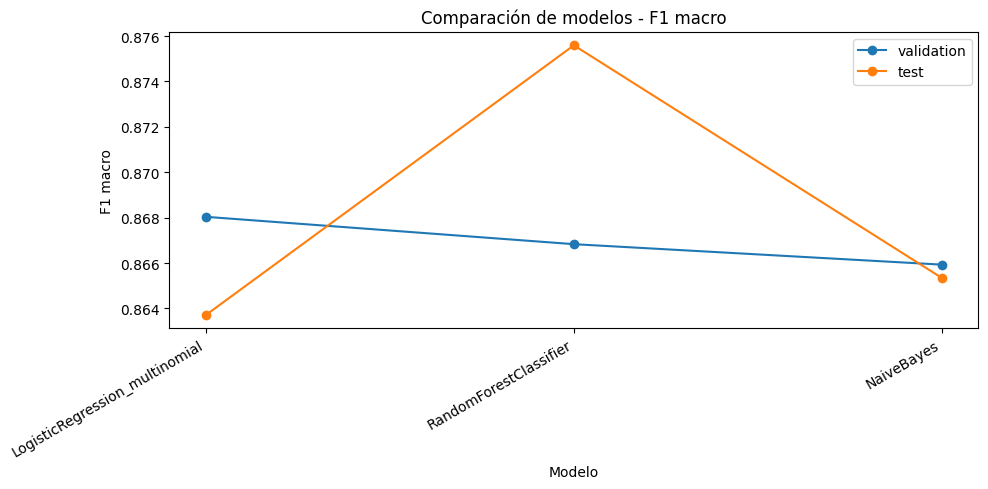

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/comparacion_modelos_f1_macro.png


In [0]:
# 11.1 Comparación de modelos por F1 macro en validation y test

metricas_pd = metricas_modelos.toPandas()
metricas_plot = metricas_pd[metricas_pd["split"].isin(["validation", "test"])].copy()

# Tabla resumen para mostrar
metricas_resumen = metricas_plot[[
    "modelo", "split", "accuracy", "balanced_accuracy", "f1_macro", "f1_weighted", "roc_auc_macro_ovr", "pr_auc_macro_ovr"
]].sort_values(["split", "f1_macro"], ascending=[True, False])

display(spark.createDataFrame(metricas_resumen))

# Gráfico F1 macro
plt.figure(figsize=(10, 5))

for split in ["validation", "test"]:
    temp = metricas_plot[metricas_plot["split"] == split]
    plt.plot(temp["modelo"], temp["f1_macro"], marker="o", label=split)

plt.title("Comparación de modelos - F1 macro")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()

ruta_fig_modelos = f"{REFINED_VISUALIZATIONS_PATH}/comparacion_modelos_f1_macro.png"
plt.savefig(ruta_fig_modelos, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", ruta_fig_modelos)

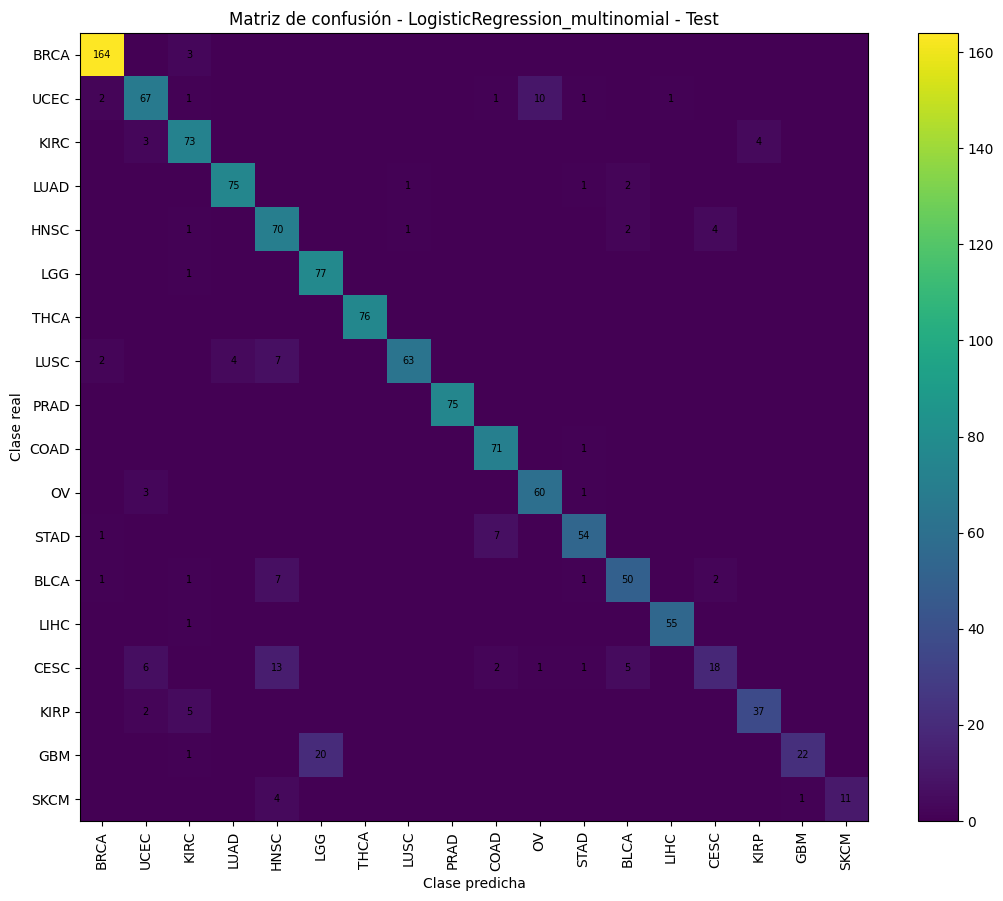

Matriz de confusión guardada en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/matriz_confusion_mejor_modelo.png


In [0]:
# 11.2 Matriz de confusión visual

plt.figure(figsize=(11, 9))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Matriz de confusión - {mejor_modelo_nombre} - Test")
plt.colorbar()

plt.xticks(np.arange(len(labels_mejor)), labels_mejor, rotation=90)
plt.yticks(np.arange(len(labels_mejor)), labels_mejor)
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

# Escribir valores principales. Si son muchos, se mantiene legible por tamaño.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=7)

plt.tight_layout()

ruta_fig_cm = f"{REFINED_VISUALIZATIONS_PATH}/matriz_confusion_mejor_modelo.png"
plt.savefig(ruta_fig_cm, dpi=300, bbox_inches="tight")
plt.show()

print("Matriz de confusión guardada en:", ruta_fig_cm)

Clases graficadas: ['BRCA', 'UCEC', 'KIRC', 'LUAD', 'LGG', 'HNSC']


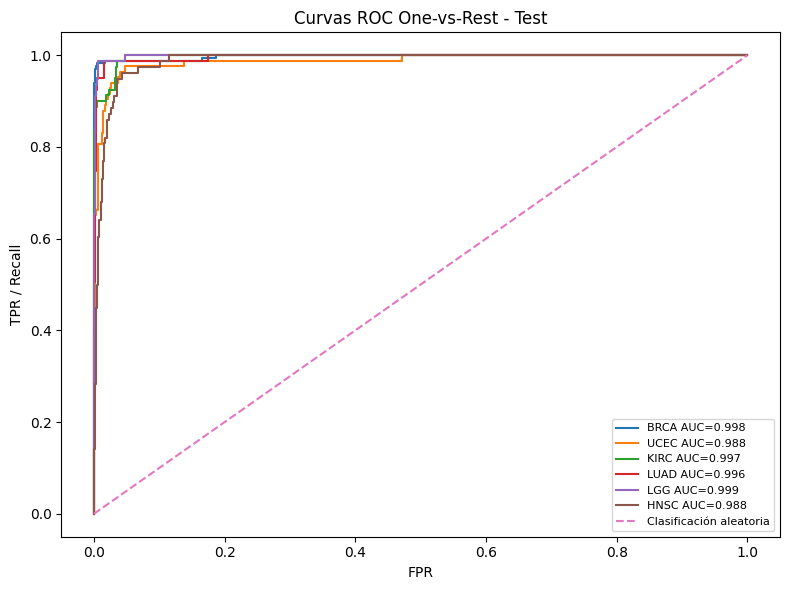

Curvas ROC guardadas en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/curvas_roc_ovr_mejor_modelo.png


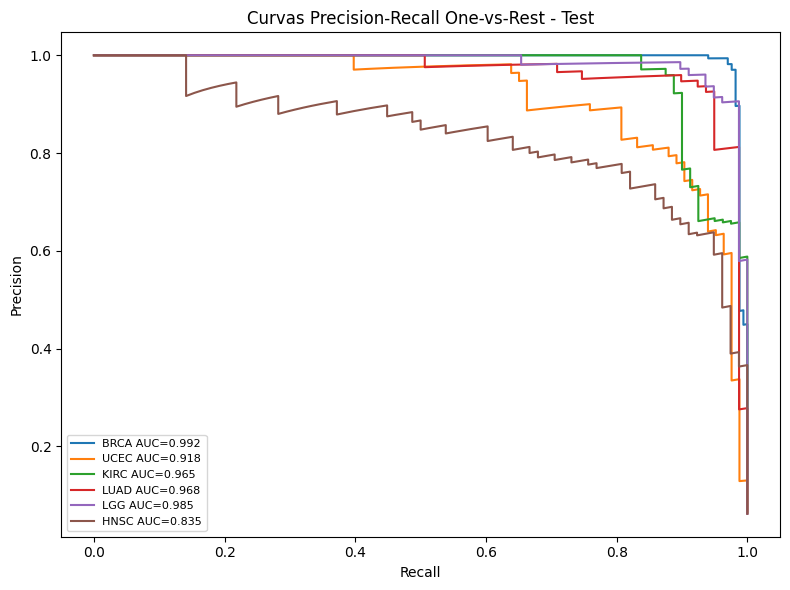

Curvas Precision-Recall guardadas en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/curvas_precision_recall_ovr_mejor_modelo.png


In [0]:
# 11.3 Curvas ROC y Precision-Recall One-vs-Rest

# Para no saturar la figura, se grafican las 6 clases con mayor soporte en test.
soporte_test = pred_test_pd["label"].value_counts().sort_values(ascending=False)
clases_a_graficar = soporte_test.head(6).index.tolist()

print("Clases graficadas:", [labels_mejor[i] for i in clases_a_graficar])

y_test_bin = label_binarize(y_test, classes=clases)

# Curva ROC
plt.figure(figsize=(8, 6))
for idx in clases_a_graficar:
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], probas_test[:, idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{labels_mejor[idx]} AUC={roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificación aleatoria")
plt.title("Curvas ROC One-vs-Rest - Test")
plt.xlabel("FPR")
plt.ylabel("TPR / Recall")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()

ruta_fig_roc = f"{REFINED_VISUALIZATIONS_PATH}/curvas_roc_ovr_mejor_modelo.png"
plt.savefig(ruta_fig_roc, dpi=300, bbox_inches="tight")
plt.show()

print("Curvas ROC guardadas en:", ruta_fig_roc)

# Curva Precision-Recall
plt.figure(figsize=(8, 6))
for idx in clases_a_graficar:
    precision, recall, _ = precision_recall_curve(y_test_bin[:, idx], probas_test[:, idx])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{labels_mejor[idx]} AUC={pr_auc:.3f}")

plt.title("Curvas Precision-Recall One-vs-Rest - Test")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()

ruta_fig_pr = f"{REFINED_VISUALIZATIONS_PATH}/curvas_precision_recall_ovr_mejor_modelo.png"
plt.savefig(ruta_fig_pr, dpi=300, bbox_inches="tight")
plt.show()

print("Curvas Precision-Recall guardadas en:", ruta_fig_pr)

El modelo seleccionado se guarda en la zona `models` para reproducibilidad.

In [0]:
# 12. Guardar mejor modelo SparkML

ruta_modelo_mejor = f"{MODELS_PATH}/{mejor_modelo_nombre}"

modelo_mejor.write().overwrite().save(ruta_modelo_mejor)

print("Mejor modelo guardado en:")
print(ruta_modelo_mejor)

Mejor modelo guardado en:
/Volumes/workspace/default/tcga_cancer_ml/models/LogisticRegression_multinomial


In [0]:
# 13. Verificación final de salidas refined y models

print("Tablas refined generadas:")
display(spark.sql("SHOW TABLES IN workspace.default LIKE 'refined_*'"))

print("Contenido de refined/model_metrics:")
display(dbutils.fs.ls(REFINED_METRICS_PATH))

print("Contenido de refined/predictions:")
display(dbutils.fs.ls(REFINED_PREDICTIONS_PATH))

print("Contenido de refined/visualizations:")
display(dbutils.fs.ls(REFINED_VISUALIZATIONS_PATH))

print("Contenido de models:")
display(dbutils.fs.ls(MODELS_PATH))

Tablas refined generadas:


database,tableName,isTemporary
default,refined_eda_calidad_datos,false
default,refined_eda_conteo_clases,false
default,refined_eda_desbalance_clases,false
default,refined_eda_expresion_global,false
default,refined_eda_genes_detectados_muestra,false
default,refined_eda_genes_mas_variables,false
default,refined_eda_muestras_por_paciente,false
default,refined_eda_resumen_general,false
default,refined_eda_tipos_muestra,false
default,refined_eda_top_genes_por_clase,false


Contenido de refined/model_metrics:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/model_metrics/metricas_modelos_sparkml/,metricas_modelos_sparkml/,0,1777742608588


Contenido de refined/predictions:


[]

Contenido de refined/visualizations:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/comparacion_modelos_f1_macro.png,comparacion_modelos_f1_macro.png,222000,1777742595000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/curvas_precision_recall_ovr_mejor_modelo.png,curvas_precision_recall_ovr_mejor_modelo.png,145010,1777742599000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/curvas_roc_ovr_mejor_modelo.png,curvas_roc_ovr_mejor_modelo.png,157316,1777742598000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/distribucion_clases.png,distribucion_clases.png,155040,1777741021000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/expresion_promedio_por_clase.png,expresion_promedio_por_clase.png,155575,1777741062000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/matriz_confusion_mejor_modelo.png,matriz_confusion_mejor_modelo.png,225823,1777742597000
dbfs:/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/top20_genes_variables.png,top20_genes_variables.png,224680,1777741084000


Contenido de models:


path,name,size,modificationTime
dbfs:/Volumes/workspace/default/tcga_cancer_ml/models/LogisticRegression_multinomial/,LogisticRegression_multinomial/,0,1777742610317
dbfs:/Volumes/workspace/default/tcga_cancer_ml/models/temp_sparkml/,temp_sparkml/,0,1777742610317
